In [27]:
from pathlib import Path

data = """Policy_ID,Policy_Group,Version,Category,Policy_Text,Benefit_Level,Coverage_Amount
P001,MED001,Old,Medical,"Covers emergency visits up to $500 and includes basic doctor consultation.",Medium,500
P002,MED001,New,Medical,"Covers emergency visits up to $750 and includes doctor consultation plus lab tests.",High,750
P003,DEN001,Old,Dental,"Covers routine dental checkups once per year and basic cleaning.",Low,100
P004,DEN001,New,Dental,"Covers routine dental checkups twice per year, basic cleaning, and X-ray services.",Medium,250
P005,VIS001,Old,Vision,"Covers one eye exam per year with partial coverage for prescription glasses.",Medium,150
P006,VIS001,New,Vision,"Covers one eye exam per year with full coverage for prescription glasses up to $300.",High,300
P007,LIFE001,Old,Life Insurance,"Provides life insurance coverage up to $10000 for eligible employees.",Medium,10000
P008,LIFE001,New,Life Insurance,"Provides life insurance coverage up to $15000 for eligible employees and includes accidental death benefits.",High,15000
P009,MED002,Old,Medical,"Covers hospital admission for up to three days and emergency care.",Medium,1000
P010,MED002,New,Medical,"Covers hospital admission for up to five days, emergency care, and follow-up visits.",High,1500
"""

data_path = Path("../data/policy_samples.csv")
data_path.write_text(data, encoding="utf-8")

print("CSV file created successfully:", data_path)

CSV file created successfully: ..\data\policy_samples.csv


In [28]:
import pandas as pd
import re
import difflib
from collections import Counter

df = pd.read_csv("../data/policy_samples.csv")
df.head()

,Policy_ID,Policy_Group,Version,Category,Policy_Text,Benefit_Level,Coverage_Amount
0,P001,MED001,Old,Medical,Covers emergency visits up to $500 and include...,Medium,500
1,P002,MED001,New,Medical,Covers emergency visits up to $750 and include...,High,750
2,P003,DEN001,Old,Dental,Covers routine dental checkups once per year a...,Low,100
3,P004,DEN001,New,Dental,"Covers routine dental checkups twice per year,...",Medium,250
4,P005,VIS001,Old,Vision,Covers one eye exam per year with partial cove...,Medium,150


In [29]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9$ ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Text"] = df["Policy_Text"].apply(clean_text)

df[["Policy_ID", "Policy_Group", "Version", "Category", "Policy_Text", "Clean_Text"]].head()

,Policy_ID,Policy_Group,Version,Category,Policy_Text,Clean_Text
0,P001,MED001,Old,Medical,Covers emergency visits up to $500 and include...,covers emergency visits up to $500 and include...
1,P002,MED001,New,Medical,Covers emergency visits up to $750 and include...,covers emergency visits up to $750 and include...
2,P003,DEN001,Old,Dental,Covers routine dental checkups once per year a...,covers routine dental checkups once per year a...
3,P004,DEN001,New,Dental,"Covers routine dental checkups twice per year,...",covers routine dental checkups twice per year ...
4,P005,VIS001,Old,Vision,Covers one eye exam per year with partial cove...,covers one eye exam per year with partial cove...


In [30]:
comparison_results = []

for group in df["Policy_Group"].unique():
    group_df = df[df["Policy_Group"] == group]
    
    if len(group_df) == 2:
        old_policy = group_df[group_df["Version"] == "Old"].iloc[0]
        new_policy = group_df[group_df["Version"] == "New"].iloc[0]
        
        old_words = set(old_policy["Clean_Text"].split())
        new_words = set(new_policy["Clean_Text"].split())
        
        added_words = new_words - old_words
        removed_words = old_words - new_words
        
        benefit_changed = old_policy["Benefit_Level"] != new_policy["Benefit_Level"]
        coverage_change = new_policy["Coverage_Amount"] - old_policy["Coverage_Amount"]
        
        comparison_results.append({
            "Policy_Group": group,
            "Category": old_policy["Category"],
            "Old_Benefit_Level": old_policy["Benefit_Level"],
            "New_Benefit_Level": new_policy["Benefit_Level"],
            "Benefit_Level_Changed": benefit_changed,
            "Old_Coverage_Amount": old_policy["Coverage_Amount"],
            "New_Coverage_Amount": new_policy["Coverage_Amount"],
            "Coverage_Change": coverage_change,
            "Added_Words": ", ".join(sorted(added_words)),
            "Removed_Words": ", ".join(sorted(removed_words)),
            "Old_Text": old_policy["Policy_Text"],
            "New_Text": new_policy["Policy_Text"]
        })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Policy_Group,Category,Old_Benefit_Level,New_Benefit_Level,Benefit_Level_Changed,Old_Coverage_Amount,New_Coverage_Amount,Coverage_Change,Added_Words,Removed_Words,Old_Text,New_Text
0,MED001,Medical,Medium,High,True,500,750,250,"$750, lab, plus, tests","$500, basic",Covers emergency visits up to $500 and include...,Covers emergency visits up to $750 and include...
1,DEN001,Dental,Low,Medium,True,100,250,150,"services, twice, xray",once,Covers routine dental checkups once per year a...,"Covers routine dental checkups twice per year,..."
2,VIS001,Vision,Medium,High,True,150,300,150,"$300, full, to, up",partial,Covers one eye exam per year with partial cove...,Covers one eye exam per year with full coverag...
3,LIFE001,Life Insurance,Medium,High,True,10000,15000,5000,"$15000, accidental, and, benefits, death, incl...",$10000,Provides life insurance coverage up to $10000 ...,Provides life insurance coverage up to $15000 ...
4,MED002,Medical,Medium,High,True,1000,1500,500,"five, followup, visits",three,Covers hospital admission for up to three days...,"Covers hospital admission for up to five days,..."


In [31]:
def classify_change(row):
    if row["Coverage_Change"] >= 1000 or row["Benefit_Level_Changed"] == True:
        return "Major Change"
    elif row["Coverage_Change"] > 0:
        return "Moderate Change"
    else:
        return "Minor Change"

comparison_df["Change_Type"] = comparison_df.apply(classify_change, axis=1)

comparison_df[[
    "Policy_Group",
    "Category",
    "Old_Benefit_Level",
    "New_Benefit_Level",
    "Coverage_Change",
    "Change_Type",
    "Added_Words",
    "Removed_Words"
]]

,Policy_Group,Category,Old_Benefit_Level,New_Benefit_Level,Coverage_Change,Change_Type,Added_Words,Removed_Words
0,MED001,Medical,Medium,High,250,Major Change,"$750, lab, plus, tests","$500, basic"
1,DEN001,Dental,Low,Medium,150,Major Change,"services, twice, xray",once
2,VIS001,Vision,Medium,High,150,Major Change,"$300, full, to, up",partial
3,LIFE001,Life Insurance,Medium,High,5000,Major Change,"$15000, accidental, and, benefits, death, incl...",$10000
4,MED002,Medical,Medium,High,500,Major Change,"five, followup, visits",three


## LLM-Assisted Summary Method

For this project, Large Language Models (LLMs) were used manually as an AI-assisted tool to summarize the differences between old and new policy wording samples.

The following prompt was used to generate clear reporting notes:

Compare the following two policy wording samples.

Old Policy:
[Old policy text]

New Policy:
[New policy text]

Please summarize:
1. Key wording differences
2. Added benefits
3. Removed or changed terms
4. Benefit-level impact
5. A short reporting note for a data analyst

In [32]:
comparison_df["LLM_Assisted_Summary"] = [
    "The medical policy increased emergency visit coverage from $500 to $750 and added lab tests, resulting in a higher benefit level.",
    "The dental policy expanded routine checkups from once to twice per year and added X-ray services, improving the benefit level.",
    "The vision policy changed from partial glasses coverage to full coverage up to $300, increasing the benefit level.",
    "The life insurance policy increased coverage from $10,000 to $15,000 and added accidental death benefits.",
    "The medical policy expanded hospital admission coverage from three to five days and added follow-up visits."
]

comparison_df[[
    "Policy_Group",
    "Category",
    "Change_Type",
    "Coverage_Change",
    "Added_Words",
    "Removed_Words",
    "LLM_Assisted_Summary"
]]

,Policy_Group,Category,Change_Type,Coverage_Change,Added_Words,Removed_Words,LLM_Assisted_Summary
0,MED001,Medical,Major Change,250,"$750, lab, plus, tests","$500, basic",The medical policy increased emergency visit c...
1,DEN001,Dental,Major Change,150,"services, twice, xray",once,The dental policy expanded routine checkups fr...
2,VIS001,Vision,Major Change,150,"$300, full, to, up",partial,The vision policy changed from partial glasses...
3,LIFE001,Life Insurance,Major Change,5000,"$15000, accidental, and, benefits, death, incl...",$10000,The life insurance policy increased coverage f...
4,MED002,Medical,Major Change,500,"five, followup, visits",three,The medical policy expanded hospital admission...


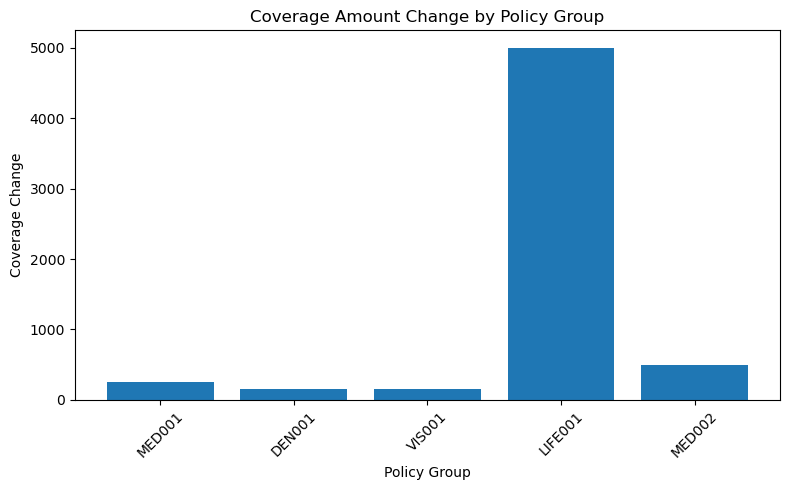

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Policy_Group"], comparison_df["Coverage_Change"])
plt.title("Coverage Amount Change by Policy Group")
plt.xlabel("Policy Group")
plt.ylabel("Coverage Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

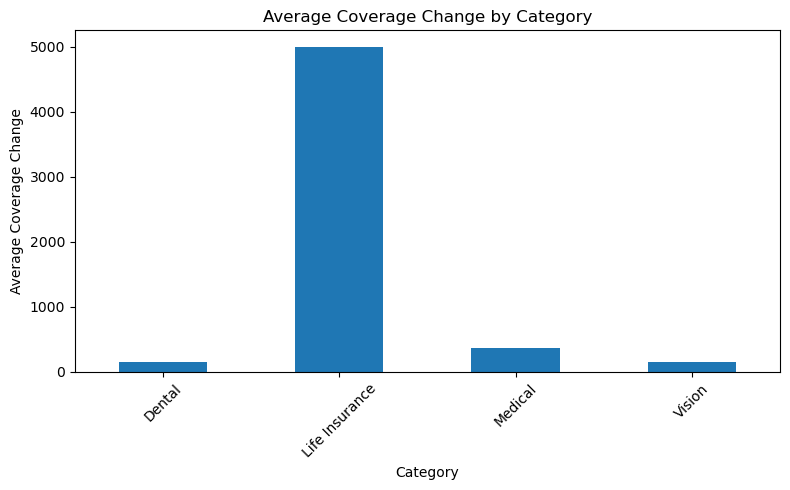

In [34]:
avg_change_by_category = comparison_df.groupby("Category")["Coverage_Change"].mean()

plt.figure(figsize=(8, 5))
avg_change_by_category.plot(kind="bar")
plt.title("Average Coverage Change by Category")
plt.xlabel("Category")
plt.ylabel("Average Coverage Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

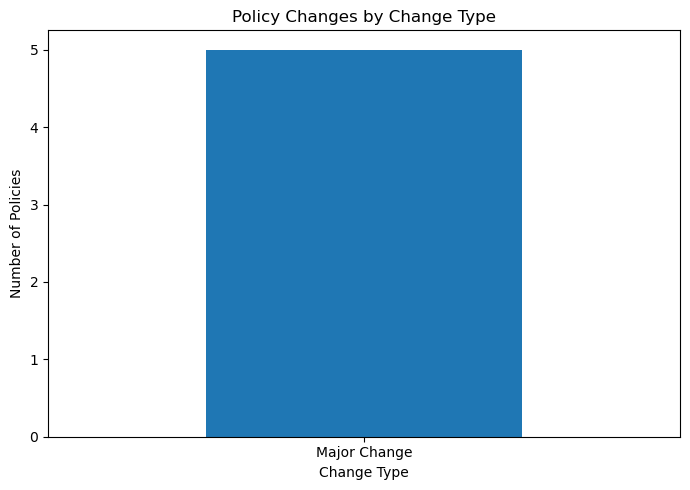

In [35]:
import matplotlib.pyplot as plt

change_counts = comparison_df["Change_Type"].value_counts()

plt.figure(figsize=(7, 5))
change_counts.plot(kind="bar")
plt.title("Policy Changes by Change Type")
plt.xlabel("Change Type")
plt.ylabel("Number of Policies")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
output_path = Path("../outputs/policy_comparison_report.xlsx")

comparison_df.to_excel(output_path, index=False)

print("Excel report exported successfully!")
print("File saved at:", output_path)

Excel report exported successfully!
File saved at: ..\outputs\policy_comparison_report.xlsx


In [37]:
print("Total policies analyzed:", len(df))
print("Total policy groups compared:", len(comparison_df))
print("Major changes:", (comparison_df["Change_Type"] == "Major Change").sum())
print("Average coverage change:", comparison_df["Coverage_Change"].mean())

Total policies analyzed: 10
Total policy groups compared: 5
Major changes: 5
Average coverage change: 1210.0
